# Tier 10b: turboshaft lapse, part-power efficiency and hover power vs the XV-15

Tier 9's powertrain was optimistic in three ways that matter for a Halo-class aircraft:

- engine power never fell with altitude;
- engine efficiency was the same at any throttle;
- hover used a 0.8 figure of merit and ignored the wing download.

Each now has an interchangeable submodel. Every default reproduces Tiers 1–9.

| Submodel | Field | Default |
|---|---|---|
| Altitude lapse, power available = rated x sigma^n | `SimpleTurboshaft.lapse_exponent` | 0 |
| Part-power efficiency knockdown (AeroSandbox / Geiss) | `SimpleTurboshaft.part_power_knockdown` | off |
| Explicit engine mass | `SimpleTurboshaft.mass_kg` | None |
| Hover download, thrust = T/W x W / (1 - f) | `SimpleAerodynamics.download_fraction_hover` | 0 |

Operating margins and flight points now pass the point's atmosphere, so the
turboshaft margin is checked against power available at altitude.

**Data** comes from NASA TM X-62407 (1975), digitized by pixel crossings of
the scanned figures:

- fig. 6.2.2: rotor shaft power available;
- fig. 5.1.1: OGE hover weight against altitude;
- sec. 6.2: engine fuel consumption (sfc) ratings.

Plus SP-4517 for the 8,650 ft hover ceiling.

```powershell
uv run jupyter lab notebooks/tier10_xv15_reference
```

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from examples.xv15_performance import (Xv15PowerData, calibrate_figure_of_merit, fit_lapse_exponent, hover_ceiling_m,
                                       hover_mass_kg, part_power_sfc_ratios, thermal_efficiency_from_sfc,
                                       tier9_hover_power_ratio, xv15_engine)
from examples.xv15_reference import Xv15Reference

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})
data = Xv15PowerData()

## 1. Defaults reproduce Tiers 1–9

With the new fields at their defaults, power available is the rated power at
any altitude, and fuel flow ignores the atmosphere.

In [2]:
engine = SimpleTurboshaft()
high = asb.Atmosphere(altitude=4000)
check("default: power available is the rating at 4 km", engine.power_available_W(high) == engine.power_rated_W)
check("default: fuel flow independent of the atmosphere",
      engine.evaluate(1e5, high).fuel_flow_kg_s == engine.evaluate(1e5).fuel_flow_kg_s)

PASS  default: power available is the rating at 4 km
PASS  default: fuel flow independent of the atmosphere


## 2. Lapse: one exponent on density ratio

The exponent is fitted by least squares to fig. 6.2.2: ln(P/P_SL) = n ln(sigma),
through the origin. The real curve is flatter low down and steeper higher up,
which is typical of a flat-rated turboshaft. One exponent is the simplest
useful model; Tier 11 engine decks can replace it.

fitted lapse exponent n = 0.797
       0 ft: digitized  1374 shp, model  1374 shp (+0.0%)
    4000 ft: digitized  1285 shp, model  1249 shp (-2.8%)
    8000 ft: digitized  1181 shp, model  1132 shp (-4.1%)
   12000 ft: digitized  1061 shp, model  1024 shp (-3.5%)
   16000 ft: digitized   942 shp, model   925 shp (-1.8%)
   20000 ft: digitized   788 shp, model   834 shp (+5.8%)
PASS  lapse within 6 % of the digitized curve to 20,000 ft
power available at the 13,000 ft Halo-class ceiling: 72.7% of sea level


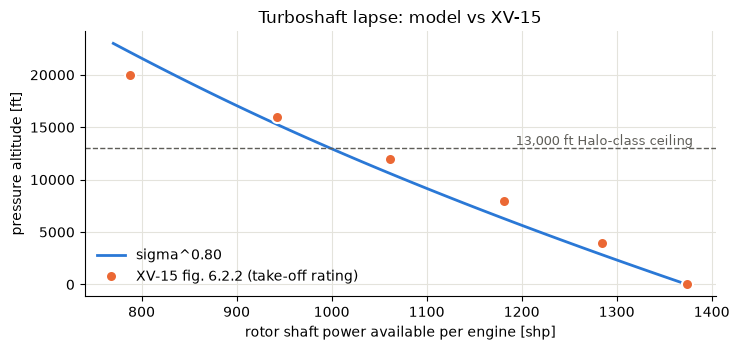

In [3]:
n = fit_lapse_exponent()
model = [float(xv15_engine(n).power_available_W(asb.Atmosphere(altitude=h))) for h in data.altitude_power_m]
print(f"fitted lapse exponent n = {n:.3f}")
for h, p, m in zip(data.altitude_power_m, data.power_available_rotor_W, model):
    print(f"  {h / u.foot:6.0f} ft: digitized {p / u.hp:5.0f} shp, model {m / u.hp:5.0f} shp ({m / p - 1:+.1%})")
check("lapse within 6 % of the digitized curve to 20,000 ft",
      all(abs(m / p - 1) < 0.06 for m, p in zip(model, data.power_available_rotor_W)))
sigma_13kft = float(asb.Atmosphere(altitude=13000 * u.foot).density() / asb.Atmosphere(altitude=0).density())
print(f"power available at the 13,000 ft Halo-class ceiling: {sigma_13kft**n:.1%} of sea level")

h_ft = np.linspace(0, 23000, 60)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot([float(xv15_engine(n).power_available_W(asb.Atmosphere(altitude=h * u.foot))) / u.hp for h in h_ft], h_ft,
        color=blue, lw=2, label=f"sigma^{n:.2f}")
ax.plot([p / u.hp for p in data.power_available_rotor_W], [h / u.foot for h in data.altitude_power_m], "o", color=orange,
        ms=8, mec="white", mew=1.5, label="XV-15 fig. 6.2.2 (take-off rating)")
ax.axhline(13000, color=ink_muted, lw=1, ls="--")
ax.text(1380, 13300, "13,000 ft Halo-class ceiling", color=ink_muted, fontsize=9, ha="right")
ax.set(xlabel="rotor shaft power available per engine [shp]", ylabel="pressure altitude [ft]",
       title="Turboshaft lapse: model vs XV-15")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

## 3. Hover: figure of merit and download

The XV-15 hover figure includes 7 % wing download and 0.93 transmission
efficiency; the power curve above is already rotor shaft power. The figure of
merit is calibrated so the sea-level hover weight uses exactly the power
available there. Every higher point is then a prediction from the lapse model
and the actuator disk. Each hover weight and the ceiling come from one
explicit Opti equality.

calibrated figure of merit: 0.670


     229 ft: figure  15578 lb, model  15578 lb (+0.0%)
    2214 ft: figure  14897 lb, model  14803 lb (-0.6%)
    4198 ft: figure  14225 lb, model  14056 lb (-1.2%)
    6183 ft: figure  13554 lb, model  13337 lb (-1.6%)
    8168 ft: figure  12882 lb, model  12646 lb (-1.8%)
   10153 ft: figure  12211 lb, model  11985 lb (-1.9%)
   20000 ft: figure   8850 lb, model   9118 lb (+3.0%)
PASS  sea-level hover weight reproduced (calibration point)
PASS  hover weights predicted within 5 % at every altitude
OGE hover ceiling at 13,000 lb: 7,141 ft (figure take-off line ~7,800 ft; SP-4517 8,650 ft)
PASS  hover ceiling within 1,000 ft of the 7,800-8,650 ft band
hover power, calibrated model / Tier 9 assumption = 1.33
PASS  Tier 9 hover power was optimistic by more than 20 %


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


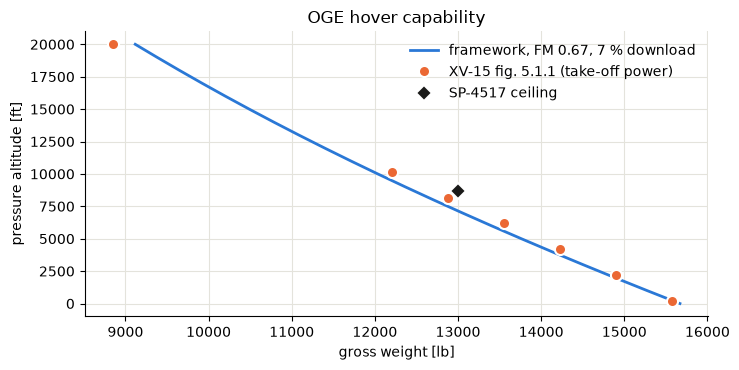

In [4]:
figure_of_merit = calibrate_figure_of_merit(n)
print(f"calibrated figure of merit: {figure_of_merit:.3f}")
predicted = [hover_mass_kg(h, figure_of_merit, n) for h in data.altitude_hover_m]
for h, m, p in zip(data.altitude_hover_m, data.mass_hover_kg, predicted):
    print(f"  {h / u.foot:6.0f} ft: figure {m / u.lbm:6.0f} lb, model {p / u.lbm:6.0f} lb ({p / m - 1:+.1%})")
check("sea-level hover weight reproduced (calibration point)", abs(predicted[0] / data.mass_hover_kg[0] - 1) < 1e-6)
check("hover weights predicted within 5 % at every altitude",
      all(abs(p / m - 1) < 0.05 for p, m in zip(predicted, data.mass_hover_kg)))
ceiling_ft = hover_ceiling_m(Xv15Reference().mass_design_kg, figure_of_merit, n) / u.foot
print(f"OGE hover ceiling at 13,000 lb: {ceiling_ft:,.0f} ft (figure take-off line ~7,800 ft; SP-4517 8,650 ft)")
check("hover ceiling within 1,000 ft of the 7,800-8,650 ft band", 6800 < ceiling_ft < 9650)
ratio = tier9_hover_power_ratio(figure_of_merit)
print(f"hover power, calibrated model / Tier 9 assumption = {ratio:.2f}")
check("Tier 9 hover power was optimistic by more than 20 %", ratio > 1.2)

alt_ft = np.linspace(0, 20000, 21)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot([hover_mass_kg(h * u.foot, figure_of_merit, n) / u.lbm for h in alt_ft], alt_ft, color=blue, lw=2,
        label=f"framework, FM {figure_of_merit:.2f}, 7 % download")
ax.plot([m / u.lbm for m in data.mass_hover_kg], [h / u.foot for h in data.altitude_hover_m], "o", color=orange, ms=8,
        mec="white", mew=1.5, label="XV-15 fig. 5.1.1 (take-off power)")
ax.plot([13000], [8650], "D", color=ink, ms=8, mec="white", mew=1.5, label="SP-4517 ceiling")
ax.set(xlabel="gross weight [lb]", ylabel="pressure altitude [ft]", title="OGE hover capability")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

## 4. Part-power fuel use

AeroSandbox's turboshaft efficiency fit includes a part-power knockdown from
Geiss (2020). The engine uses it as a ratio, so its own full-power efficiency
stays an explicit input. Throttle is shaft power over power available; for the
LTC1K-4K the maximum is the contingency rating.

In [5]:
rows = part_power_sfc_ratios()
for throttle, published, model in rows:
    print(f"  throttle {throttle:.3f}: published sfc ratio {published:.3f}, model {model:.3f}")
check("knockdown matches the four LTC1K-4K ratings within 2 %", all(abs(m / p - 1) < 0.02 for _, p, m in rows))
check("knockdown is 1 at full throttle", abs(rows[0][2] - 1) < 1e-12)
eta = thermal_efficiency_from_sfc(0.564)
print(f"LTC1K-4K thermal efficiency at contingency: {eta:.3f} (Tier 1 default 0.30)")
check("published sfc implies 0.24 thermal efficiency (a 1950s-design engine)", abs(eta - 0.244) < 0.002)

  throttle 1.000: published sfc ratio 1.000, model 1.000
  throttle 0.860: published sfc ratio 1.035, model 1.039
  throttle 0.777: published sfc ratio 1.066, model 1.065
  throttle 0.694: published sfc ratio 1.103, model 1.096
PASS  knockdown matches the four LTC1K-4K ratings within 2 %
PASS  knockdown is 1 at full throttle
LTC1K-4K thermal efficiency at contingency: 0.244 (Tier 1 default 0.30)
PASS  published sfc implies 0.24 thermal efficiency (a 1950s-design engine)


## 5. What changes for the Halo-class sizing (plan 013)

- **Hover power is about a third higher than Tier 9 assumed.** Hover sized the
  Tier 9 motors, gearboxes and rotors, so they grow. Plan 013 will choose a
  figure of merit (the XV-15's 0.67 is a 1970s metal-blade value) and a
  download fraction, and document both.
- **The turboshaft must be sized at altitude.** At the 13,000 ft ceiling only
  about 72 % of sea-level power is available.
- **Part-power fuel burn is now penalized.** The battery-versus-generator
  split is no longer free at low throttle.
- **Not validated yet: airplane-mode cruise power.** Checking it needs an
  XV-15 drag polar and a propeller-mode rotor efficiency.

## 6. Summary and unit test suite

In [6]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

10 / 10 notebook checks passed


In [7]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 310 tests in 69.853s

OK
